In [15]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [16]:
!pip install yfinance
import yfinance as yf

In [17]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [60]:
df = yf.download("NVDA", start ="2020-01-01", end = "2026-01-01")
print(df.head())

features = df[["Close", "High", "Low", "Volume"]].values

/tmp/ipykernel_55/1618768524.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("NVDA", start ="2020-01-01", end = "2026-01-01")
[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2020-01-02  5.970753  5.970753  5.891363  5.941884  237536000
2020-01-03  5.875186  5.918989  5.826158  5.851046  205384000
2020-01-06  5.899826  5.905052  5.755727  5.781859  262636000
2020-01-07  5.971253  6.017046  5.883151  5.928197  314856000
2020-01-08  5.982451  6.023765  5.926952  5.967021  277108000


In [61]:
# scale dữ liệu

scaler = MinMaxScaler()
data = scaler.fit_transform(features)
print(data.max())

1.0


In [ ]:
# Tạo bộ dữ liệu nhãn
SEQ_LEN = 60

def make_lable(data, seq_len):
    X, y = [], []

    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i+seq_len, 0])  # Chỉ lấy cột Close (index 0)
    return np.array(X), np.array(y)

X, y = make_lable(data, SEQ_LEN)
print(X[0])
print(y[0])

[[0.00534284 0.00358923 0.00692408 0.11634844]
 [0.00487004 0.00333908 0.00659974 0.09460035]
 [0.00499194 0.00327174 0.0062494  0.13332646]
 [0.00534532 0.00381293 0.00688323 0.16864884]
 [0.00540072 0.0038454  0.00710111 0.14311553]
 [0.00572577 0.00431323 0.00743659 0.12823711]
 [0.00588584 0.00462832 0.00779435 0.16962288]
 [0.00682901 0.0051623  0.00816574 0.1720201 ]
 [0.00625031 0.00495665 0.00816574 0.19856803]
 [0.00603975 0.00464516 0.00789092 0.13364302]
 [0.00645347 0.00470289 0.00816946 0.14790726]
 [0.00649656 0.0048027  0.00824249 0.12734424]
 [0.00633157 0.00471733 0.00814346 0.10307718]
 [0.00659875 0.00523445 0.00844427 0.11750105]
 [0.00693736 0.00518756 0.00833906 0.12106982]
 [0.00664432 0.00594523 0.00835762 0.20832464]
 [0.00537856 0.00387066 0.00636824 0.27395312]
 [0.00633527 0.00471492 0.00741802 0.16602435]
 [0.00603606 0.0046632  0.00781788 0.1307642 ]
 [0.0060693  0.00436374 0.00725585 0.15217679]
 [0.00491436 0.00413523 0.0066802  0.20623316]
 [0.00539456 

In [63]:
# Chia du lieu
ti_le = int(len(data) * 0.7)
X_train, X_test = X[:ti_le], X[ti_le:]
y_train, y_test = y[:ti_le], y[ti_le:]

Thực hiện bọc dữ liệu vào Dataset do torch yêu cầu vậy.
Chuyển numpy array sang Tensor PyTorch và đóng gói lại để PyTorch có thể đọc được

Tạo dataloader, chia thành từng bactch để huấn luyện

In [64]:
from torch.utils.data import Dataset, DataLoader
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype = torch.float32)
        self.y = torch.tensor(y, dtype = torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

X_batch, y_batch = next(iter(train_loader))

print(X_batch.shape)

torch.Size([32, 60, 4])


In [69]:
# Xay dung mo hinh
class LSTMr(nn.Module):
    def __init__(self, input_size = 4, hidden_size = 256, num_layers = 5, output_size = 1):
        super(LSTMr, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = 0.1,
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward (self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, (hn, cn) = self.lstm(x, (h0, c0))

        out = out[:, -1, :]
        out = self.fc(out)

        return out

model = LSTMr()
print (model)
tong_tham_so = sum(p.numel() for p in model.parameters())
print("Tổng tham số: ", tong_tham_so)

LSTMr(
  (lstm): LSTM(4, 256, num_layers=5, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
Tổng tham số:  2373889


In [71]:
# Train model
l = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

its = 200
l_train = []

for it in range(its):
    model.train()
    it_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)

        loss = l(y_pred, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        it_loss += loss.item()

    avg_loss = it_loss / len(train_loader)
    l_train.append(avg_loss)
    if (it + 1) % 10 == 0:
        print(f"Epoch [{it+1}/{its}] Loss: {avg_loss:.6f}")

Epoch [10/200] Loss: 0.011762
Epoch [20/200] Loss: 0.011177
Epoch [30/200] Loss: 0.010789
Epoch [40/200] Loss: 0.010654
Epoch [50/200] Loss: 0.010438
Epoch [60/200] Loss: 0.010323
Epoch [70/200] Loss: 0.010293
Epoch [80/200] Loss: 0.010284
Epoch [90/200] Loss: 0.010299
Epoch [100/200] Loss: 0.009961
Epoch [110/200] Loss: 0.010018
Epoch [120/200] Loss: 0.010051
Epoch [130/200] Loss: 0.009953
Epoch [140/200] Loss: 0.009999
Epoch [150/200] Loss: 0.009960
Epoch [160/200] Loss: 0.010004
Epoch [170/200] Loss: 0.009972
Epoch [180/200] Loss: 0.009915
Epoch [190/200] Loss: 0.009957
Epoch [200/200] Loss: 0.009888


In [77]:
print(y.shape)

(1448, 4)


(393, 1)
(393, 4)
MAE: $38.41


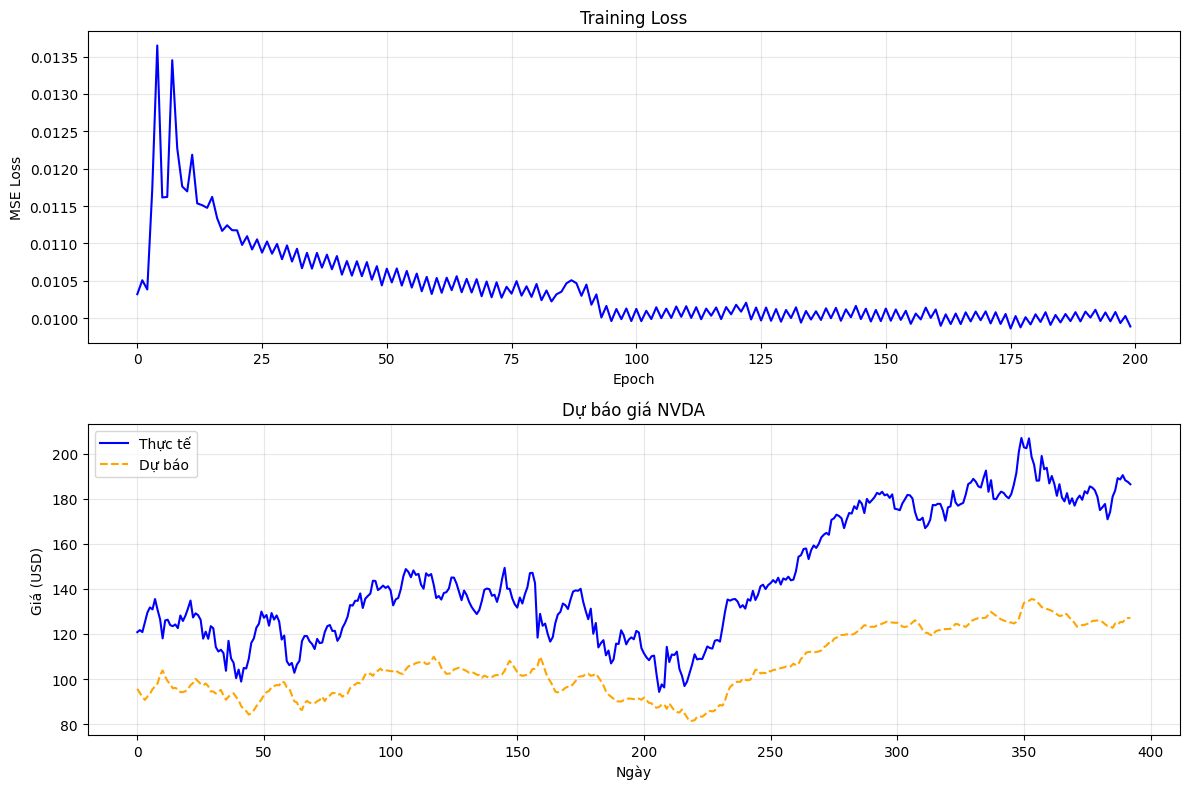

In [ ]:
predictions = []
actuals = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        predictions.extend(y_pred.numpy())
        actuals.extend(y_batch.numpy())

# Chuyển đổi sang numpy array
predictions = np.array(predictions).flatten()
actuals = np.array(actuals).flatten()

print(f"Predictions shape: {predictions.shape}")
print(f"Actuals shape: {actuals.shape}")
print(f"Predictions min/max (scaled): {predictions.min():.4f} / {predictions.max():.4f}")
print(f"Actuals min/max (scaled): {actuals.min():.4f} / {actuals.max():.4f}")

# Inverse transform chính xác cho cột Close (index 0)
dummy_pred = np.zeros((len(predictions), 4))
dummy_pred[:, 0] = predictions
predictions_real = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_actual = np.zeros((len(actuals), 4))
dummy_actual[:, 0] = actuals
actuals_real = scaler.inverse_transform(dummy_actual)[:, 0]

mae = np.mean(np.abs(predictions_real - actuals_real))
bias = np.mean(predictions_real - actuals_real)
print(f"\nMAE: ${mae:.2f}")
print(f"Bias (trung bình sai lệch): ${bias:.2f}")
print(f"Mean actual: ${actuals_real.mean():.2f}")
print(f"Mean prediction: ${predictions_real.mean():.2f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(l_train, color='blue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(actuals_real,     label='Thực tế', color='blue')
axes[1].plot(predictions_real, label='Dự báo',  color='orange', linestyle='--')
axes[1].set_title('Dự báo giá NVDA')
axes[1].set_xlabel('Ngày')
axes[1].set_ylabel('Giá (USD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()